# Resume Screening Analysis

Pipeline:
1. **Parse** — อ่านไฟล์ resume (.txt) → plain text
2. **NER Extraction** — Layer 1 (spaCy) + Layer 2 (HF skills model)
3. **Similarity Matching** — sentence-transformers vs Job Description
4. **Ranking + Visualisation** — เปรียบเทียบ candidates

In [1]:
import sys
sys.path.insert(0, '..')  # add project root to path

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

pd.set_option('display.max_colwidth', 80)
print('Ready ✓')

Ready ✓


## 1. Parse Resumes

In [2]:
from src.parsers.resume_parser import parse_resume

RAW_DIR = Path('../data/raw')

resume_files = sorted(RAW_DIR.glob('resume_*.txt'))
jd_text = (RAW_DIR / 'job_description.txt').read_text(encoding='utf-8')

print(f'Found {len(resume_files)} resume files')
print(f'JD length: {len(jd_text)} chars\n')

resumes = []
for f in resume_files:
    text = parse_resume(f)
    resumes.append({'file': f.name, 'text': text})
    print(f'  ✓ {f.name} ({len(text)} chars)')

18:24:40 [INFO] src.parsers.resume_parser — [TXT] resume_01_alice_chen.txt → 855 chars
18:24:40 [INFO] src.parsers.resume_parser — [TXT] resume_02_bob_smith.txt → 642 chars
18:24:40 [INFO] src.parsers.resume_parser — [TXT] resume_03_carol_ng.txt → 799 chars
18:24:40 [INFO] src.parsers.resume_parser — [TXT] resume_04_david_wilson.txt → 819 chars
18:24:40 [INFO] src.parsers.resume_parser — [TXT] resume_05_eva_martinez.txt → 963 chars
18:24:40 [INFO] src.parsers.resume_parser — [TXT] resume_06_frank_tanaka.txt → 785 chars
18:24:40 [INFO] src.parsers.resume_parser — [TXT] resume_07_grace_kim.txt → 804 chars
18:24:40 [INFO] src.parsers.resume_parser — [TXT] resume_08_henry_liu.txt → 955 chars
18:24:40 [INFO] src.parsers.resume_parser — [TXT] resume_09_iris_patel.txt → 919 chars
18:24:40 [INFO] src.parsers.resume_parser — [TXT] resume_10_james_okonkwo.txt → 966 chars


Found 10 resume files
JD length: 1174 chars

  ✓ resume_01_alice_chen.txt (855 chars)
  ✓ resume_02_bob_smith.txt (642 chars)
  ✓ resume_03_carol_ng.txt (799 chars)
  ✓ resume_04_david_wilson.txt (819 chars)
  ✓ resume_05_eva_martinez.txt (963 chars)
  ✓ resume_06_frank_tanaka.txt (785 chars)
  ✓ resume_07_grace_kim.txt (804 chars)
  ✓ resume_08_henry_liu.txt (955 chars)
  ✓ resume_09_iris_patel.txt (919 chars)
  ✓ resume_10_james_okonkwo.txt (966 chars)


## 2. NER Extraction (Layer 1 + Layer 2)

In [3]:
from src.ner.extractor import extract

print('Running NER on all resumes (HF model downloads on first run)...\n')

for r in resumes:
    r['entities'] = extract(r['text'])

print('\nDone!')

18:24:40 [INFO] src.ner.extractor — Running NER extraction …


Running NER on all resumes (HF model downloads on first run)...



18:24:51 [INFO] src.ner.spacy_ner — Loading spaCy model: en_core_web_sm
18:24:53 [INFO] src.ner.spacy_ner — [spaCy] persons=7 companies=7 dates=4 locations=4
c:\Users\khala\MyDocuments\00_DS\000_Projects_DS_Git\llm_resume_screening\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
18:26:49 [INFO] src.ner.hf_ner — Loading HF NER model: algiraldohe/lm-ner-linkedin-skills-recognition (downloads on first use)
18:26:50 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/algiraldohe/lm-ner-linkedin-skills-recognition/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
18:26:50 [WARNING] huggingface_hub.utils._http — Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
18:26:51 [INFO] httpx — HTTP Request: HEAD https://hu


Done!


In [4]:
# ดู entities ของ candidate แรก
sample = resumes[0]
print(f"=== {sample['file']} ===")
for key, vals in sample['entities'].items():
    print(f"  {key:12s}: {vals}")

=== resume_01_alice_chen.txt ===
  persons     : ['Alice Chen\nEmail', 'PyTorch', 'Docker', 'Git', 'Pandas', 'Matplotlib', 'PySpark']
  companies   : ['NLP', 'TensorFlow', 'Hugging Face Transformers', 'SQL', 'XGBoost', 'Chulalongkorn University', 'Kasetsart University']
  dates       : ['6 years', '2021', '2018', '2016']
  locations   : ['Bangkok', 'Thailand', 'AI', 'NumPy']
  skills      : ['machine learning', 'nlp', 'ai', 'pipelines', 'python', 'pytorch', 'tensorflow', 'transformers', 'spacy', 'sql', 'git', 'fastapi', 'pandas', 'numpy', 'matplotlib', 'airflow', 'fraud detection', 'etl', 'pyspark', 'education', 'computer science', 'statistics']


In [5]:
# สรุป NER ทุก candidate ใน DataFrame
ner_rows = []
for r in resumes:
    e = r['entities']
    ner_rows.append({
        'Candidate':      r['file'].replace('resume_', '').replace('.txt', ''),
        'Skills':         ', '.join(e.get('skills', [])),
        'Companies':      ', '.join(e.get('companies', [])),
        'Dates':          ', '.join(e.get('dates', [])),
        '#Skills':        len(e.get('skills', [])),
        '#Companies':     len(e.get('companies', [])),
    })

df_ner = pd.DataFrame(ner_rows)
df_ner

,Candidate,Skills,Companies,Dates,#Skills,#Companies
0,01_alice_chen,"machine learning, nlp, ai, pipelines, python, pytorch, tensorflow, transform...","NLP, TensorFlow, Hugging Face Transformers, SQL, XGBoost, Chulalongkorn Univ...","6 years, 2021, 2018, 2016",22,7
1,02_bob_smith,"python, data science, machine learning, pandas, numpy, matplotlib, sql, git,...","SQL, TechCorp, B.Sc., Information Technology — University","1.5 years, 2023, 2022",19,4
2,03_carol_ng,"machine learning, computer vision, deep learning, python, pytorch, opencv, k...","Machine Learning Engineer, Kubernetes, CI, MLflow, Weights & Biases, ML Engi...","4 years, 2022, 2020, 2018",17,11
3,04_david_wilson,"investment banking, vba, bloomberg, sql, valuation, dcf, data extraction, re...","Experienced Financial, VBA, Bloomberg Terminal, SQL, PowerPoint, Financial M...","8 years, 2019, 2016, 2014",11,13
4,05_eva_martinez,"nlp, large language models, text generation, information extraction, python,...","NLP Research Scientist, NLTK, PyTorch, BERT, GPT, LangChain, SQL, NER, ACL, ...","5 years, 2022, 2019, 2015",20,10
5,06_frank_tanaka,"scalable, web applications, data science, javascript, typescript, postgresql...","TypeScript, Redis, Docker, AWS, S3, RDS, Full-Stack Developer — Rakuten, B.S...","5 years, 2021, 2019",16,9
6,07_grace_kim,"python, sql, business intelligence, pandas, numpy, tableau, bi, looker, test...","SQL, Power BI, Looker, Statistics, BigQuery, LG Electronics, Applied Statist...","3 years, 2022, weekly, 2021",16,8
7,08_henry_liu,"ai, machine learning, python, mlops, cloud infrastructure, pytorch, keras, s...","AI/ML Engineer, MLOps, XGBoost, SQL, Kubernetes, AWS, GCP, Terraform, ML Eng...","7 years, 2020, 2 weeks, 2017, 2015",20,16
8,09_iris_patel,"human resources, employee relations, hris, sap, hr, performance management, ...","HRIS, Performance Management, Employee Relations, Training & Development, MS...","10 years, Workday, 2018, 90-day, 2014, 2012",18,7
9,10_james_okonkwo,"data science, fintech, python, nlp, tensorflow, nltk, spacy, sql, postgresql...","ML, NLP, TensorFlow, NLTK, Celery, BERT, Isolation Forest","6 years, 2021, 2018, 2016",23,7


### Skills count per candidate

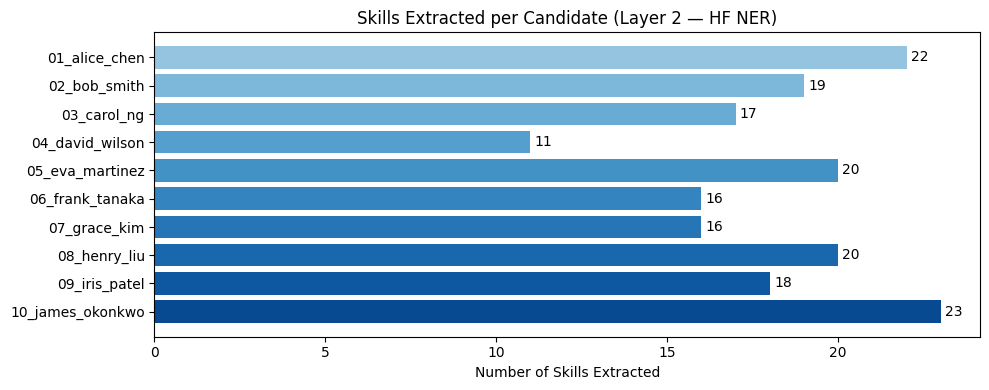

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = cm.Blues(np.linspace(0.4, 0.9, len(df_ner)))
bars = ax.barh(df_ner['Candidate'], df_ner['#Skills'], color=colors)
ax.bar_label(bars, padding=3)
ax.set_xlabel('Number of Skills Extracted')
ax.set_title('Skills Extracted per Candidate (Layer 2 — HF NER)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Similarity Matching vs Job Description

In [7]:
from src.matching.similarity import rank_candidates

print('Job Description (first 300 chars):')
print(jd_text[:300], '...')

print('\nEncoding + ranking (model downloads on first run)...')
ranked = rank_candidates(resumes, jd_text, top_n=10)
print(f'\nRanked {len(ranked)} candidates')

Job Description (first 300 chars):
Job Title: Senior Data Scientist / NLP Engineer

Company: TechCorp AI

About the Role:
We are looking for a Senior Data Scientist with strong NLP expertise to join
our AI team. You will build and deploy machine learning models that process
and understand human language at scale.

Responsibilities:
- ...

Encoding + ranking (model downloads on first run)...


18:27:38 [INFO] src.matching.similarity — Loading embedding model: all-MiniLM-L6-v2
18:27:38 [INFO] sentence_transformers.base.model — No device provided, using cpu
18:27:40 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
18:27:41 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
18:27:41 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
18:27:41 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
18:27:41 [INFO] sentence_transformers.base.model — Loading 


Ranked 10 candidates


In [8]:
# แสดงผลการ rank
df_rank = pd.DataFrame([
    {
        'Rank':       i + 1,
        'Candidate':  r['file'].replace('resume_', '').replace('.txt', ''),
        'Score':      r['score'],
        'Skills':     ', '.join(r['entities'].get('skills', [])[:5]) + ('…' if len(r['entities'].get('skills', [])) > 5 else ''),
    }
    for i, r in enumerate(ranked)
])

df_rank.style.background_gradient(subset=['Score'], cmap='RdYlGn')

,Rank,Candidate,Score,Skills
0,1,08_henry_liu,0.632400,"ai, machine learning, python, mlops, cloud infrastructure…"
1,2,05_eva_martinez,0.632000,"nlp, large language models, text generation, information extraction, python…"
2,3,01_alice_chen,0.608700,"machine learning, nlp, ai, pipelines, python…"
3,4,10_james_okonkwo,0.538700,"data science, fintech, python, nlp, tensorflow…"
4,5,03_carol_ng,0.533800,"machine learning, computer vision, deep learning, python, pytorch…"
5,6,07_grace_kim,0.494900,"python, sql, business intelligence, pandas, numpy…"
6,7,02_bob_smith,0.487700,"python, data science, machine learning, pandas, numpy…"
7,8,09_iris_patel,0.447200,"human resources, employee relations, hris, sap, hr…"
8,9,06_frank_tanaka,0.426900,"scalable, web applications, data science, javascript, typescript…"
9,10,04_david_wilson,0.317300,"investment banking, vba, bloomberg, sql, valuation…"


### Similarity Score Bar Chart

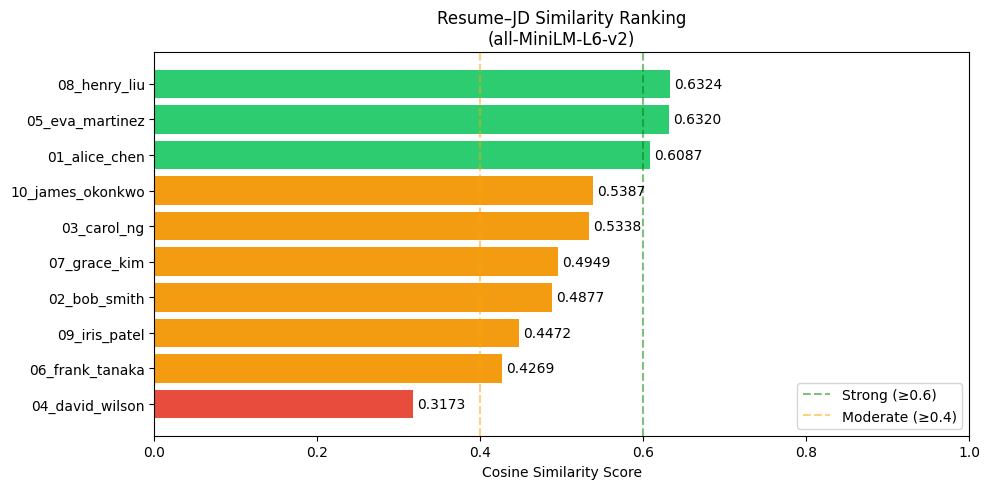

In [9]:
scores  = [r['score'] for r in ranked]
labels  = [r['file'].replace('resume_', '').replace('.txt', '') for r in ranked]
colors  = ['#2ecc71' if s >= 0.6 else '#f39c12' if s >= 0.4 else '#e74c3c' for s in scores]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, scores, color=colors)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_xlim(0, 1)
ax.axvline(0.6, color='green',  linestyle='--', alpha=0.5, label='Strong (≥0.6)')
ax.axvline(0.4, color='orange', linestyle='--', alpha=0.5, label='Moderate (≥0.4)')
ax.set_xlabel('Cosine Similarity Score')
ax.set_title('Resume–JD Similarity Ranking\n(all-MiniLM-L6-v2)')
ax.invert_yaxis()
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Deep Dive — Top 3 Candidates

In [10]:
for r in ranked[:3]:
    e = r['entities']
    print(f"{'='*55}")
    print(f"  {r['file']}  |  Score: {r['score']:.4f}")
    print(f"{'='*55}")
    print(f"  Skills    : {', '.join(e.get('skills', []))}")
    print(f"  Companies : {', '.join(e.get('companies', []))}")
    print(f"  Dates     : {', '.join(e.get('dates', []))}")
    print(f"  Locations : {', '.join(e.get('locations', []))}")
    print()

  resume_08_henry_liu.txt  |  Score: 0.6324
  Skills    : ai, machine learning, python, mlops, cloud infrastructure, pytorch, keras, sql, airflow, kubernetes, aws, gcp, mlflow, terraform, grafana, shopify, pipelines, education, computer science, mathematics
  Companies : AI/ML Engineer, MLOps, XGBoost, SQL, Kubernetes, AWS, GCP, Terraform, ML Engineer — Shopify, ML, GCP Vertex AI, RBC, Royal Bank of Canada, Spark, University of Toronto, McGill University
  Dates     : 7 years, 2020, 2 weeks, 2017, 2015
  Locations : Toronto, Canada, Prometheus

  resume_05_eva_martinez.txt  |  Score: 0.6320
  Skills    : nlp, large language models, text generation, information extraction, python, transformers, spacy, nltk, pytorch, bert, ##n, fastapi, git, sql, ai, spanish, entity recognition, education, computational linguistics, artificial intelligence
  Companies : NLP Research Scientist, NLTK, PyTorch, BERT, GPT, LangChain, SQL, NER, ACL, Universidad Autónoma de Madrid
  Dates     : 5 years, 2022, 

## 5. Score Distribution

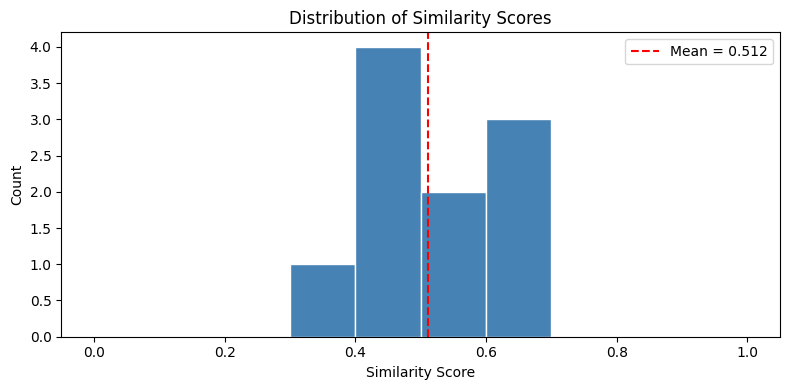

Mean  : 0.5120
Max   : 0.6324
Min   : 0.3173
Std   : 0.0947


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores, bins=10, range=(0, 1), color='steelblue', edgecolor='white')
ax.set_xlabel('Similarity Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Similarity Scores')
ax.axvline(np.mean(scores), color='red', linestyle='--', label=f'Mean = {np.mean(scores):.3f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean  : {np.mean(scores):.4f}')
print(f'Max   : {np.max(scores):.4f}')
print(f'Min   : {np.min(scores):.4f}')
print(f'Std   : {np.std(scores):.4f}')